In [45]:
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme('notebook')
from encoder import LSTMEncoder
import torch
from dataset import load_and_split_data, create_vector_dataset

In [2]:
cat_coverage = 0.99
cat_features = ["MCC", "trx_category"]
enc_train_dataset, enc_val_dataset, classifier_cv_dataset, test_dataset, vocab_sizes = load_and_split_data(
    "pytorch-lifestream/rosbank-churn", 
    "pytorch-lifestream/rosbank-churn",
    cat_features=cat_features,
    cat_coverage=cat_coverage
)
checkpoint_path = "model_checkpoint.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
import dagshub
dagshub.init("event-sequence-embeddings", "reizkh")

Accessing as reizkh

Initialized MLflow to track repo "reizkh/event-sequence-embeddings"

Repository reizkh/event-sequence-embeddings initialized!

In [4]:
run_id = "afe3cbce965b4decb7db2e76546401ed"
checkpoint_path = "model_checkpoint.pth"


with mlflow.start_run(run_id=run_id) as mlflow_run:
    path = mlflow.artifacts.download_artifacts(
        run_id=mlflow_run.info.run_id,
        artifact_path="models/best_model/" + checkpoint_path
    )
    encoder = LSTMEncoder(
        cat_vocab_sizes=vocab_sizes,
        hidden_size=int(mlflow_run.data.params["embedding_size"]),
        cat_embedding_dims=[128, 128]
    ).to(device)
    encoder.load_state_dict(torch.load(path, map_location=device))

    vector_dataset, labels = create_vector_dataset(
        encoder,
        enc_train_dataset,
        int(mlflow_run.data.params["embedding_size"]),
        device
    )

Creating vector dataset: 100%|██████████| 137/137 [00:08<00:00, 16.76it/s]


🏃 View run intelligent-moth-36 at: https://dagshub.com/reizkh/event-sequence-embeddings.mlflow/#/experiments/11/runs/afe3cbce965b4decb7db2e76546401ed
🧪 View experiment at: https://dagshub.com/reizkh/event-sequence-embeddings.mlflow/#/experiments/11


In [5]:
from sklearn.metrics import pairwise_distances
import numpy as np

In [12]:
d1 = np.tril(pairwise_distances(vector_dataset, metric="euclidean")).flatten()
# a = pairwise_distances(vector_dataset, metric="cosine").flatten()

In [ ]:
# np.corrcoef(d1, np.log(a+0.05))

array([[1.       , 0.9979061],
       [0.9979061, 1.       ]])

In [13]:
d1 = d1[d1 != 0]

<Axes: ylabel='Count'>

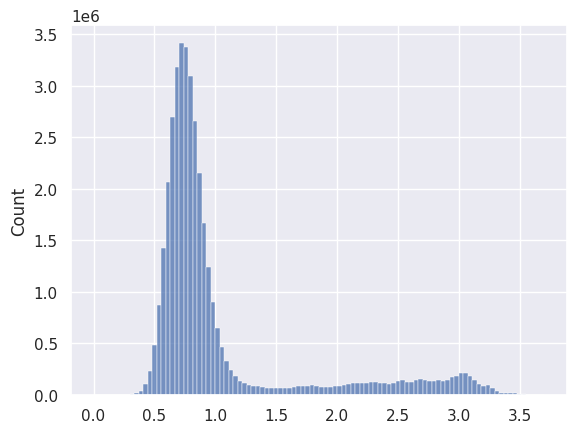

In [8]:
sns.histplot(d1, bins=100)

In [7]:
import gc
gc.collect()

124

In [14]:
d1 = d1[d1>1.1]

<Axes: ylabel='Count'>

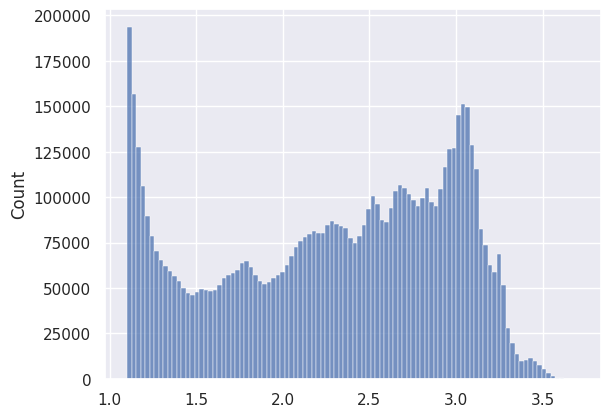

In [15]:
sns.histplot(d1, bins=100)

<Axes: ylabel='Count'>

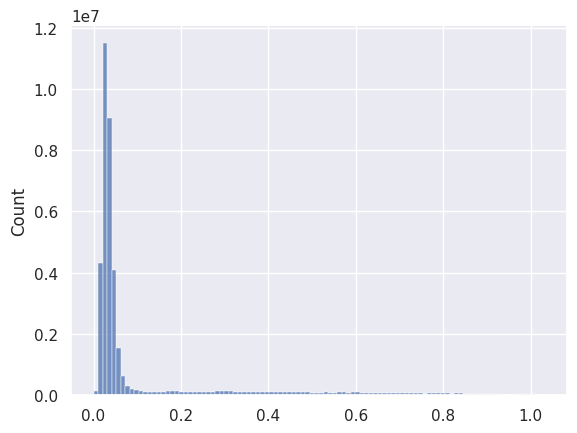

In [8]:
a = np.tril(pairwise_distances(vector_dataset, metric="cosine")).flatten()
a = a[a != 0]
sns.histplot(a, bins=100)

In [82]:
centroid = vector_dataset.mean(axis=0)
np.linalg.norm(centroid)

np.float64(2.853708652217393)

In [ ]:
rng = np.random.default_rng()
n = 128

<Axes: >

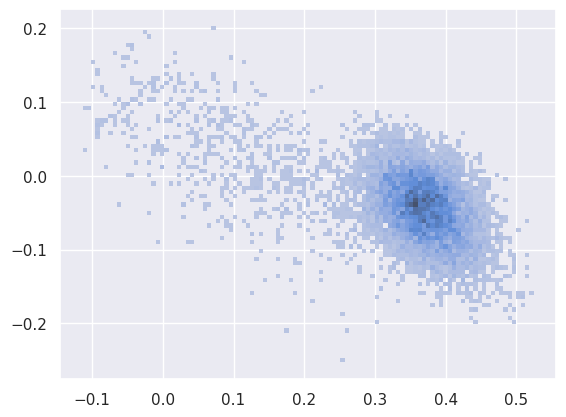

In [87]:
v = rng.standard_normal((n, 2))
v /= np.linalg.norm(v, axis=0)
x_ = vector_dataset @ v[:,0]
y_ = vector_dataset @ v[:,1]
sns.histplot(x=x_, y=y_)

In [43]:
import statsmodels.api as sm

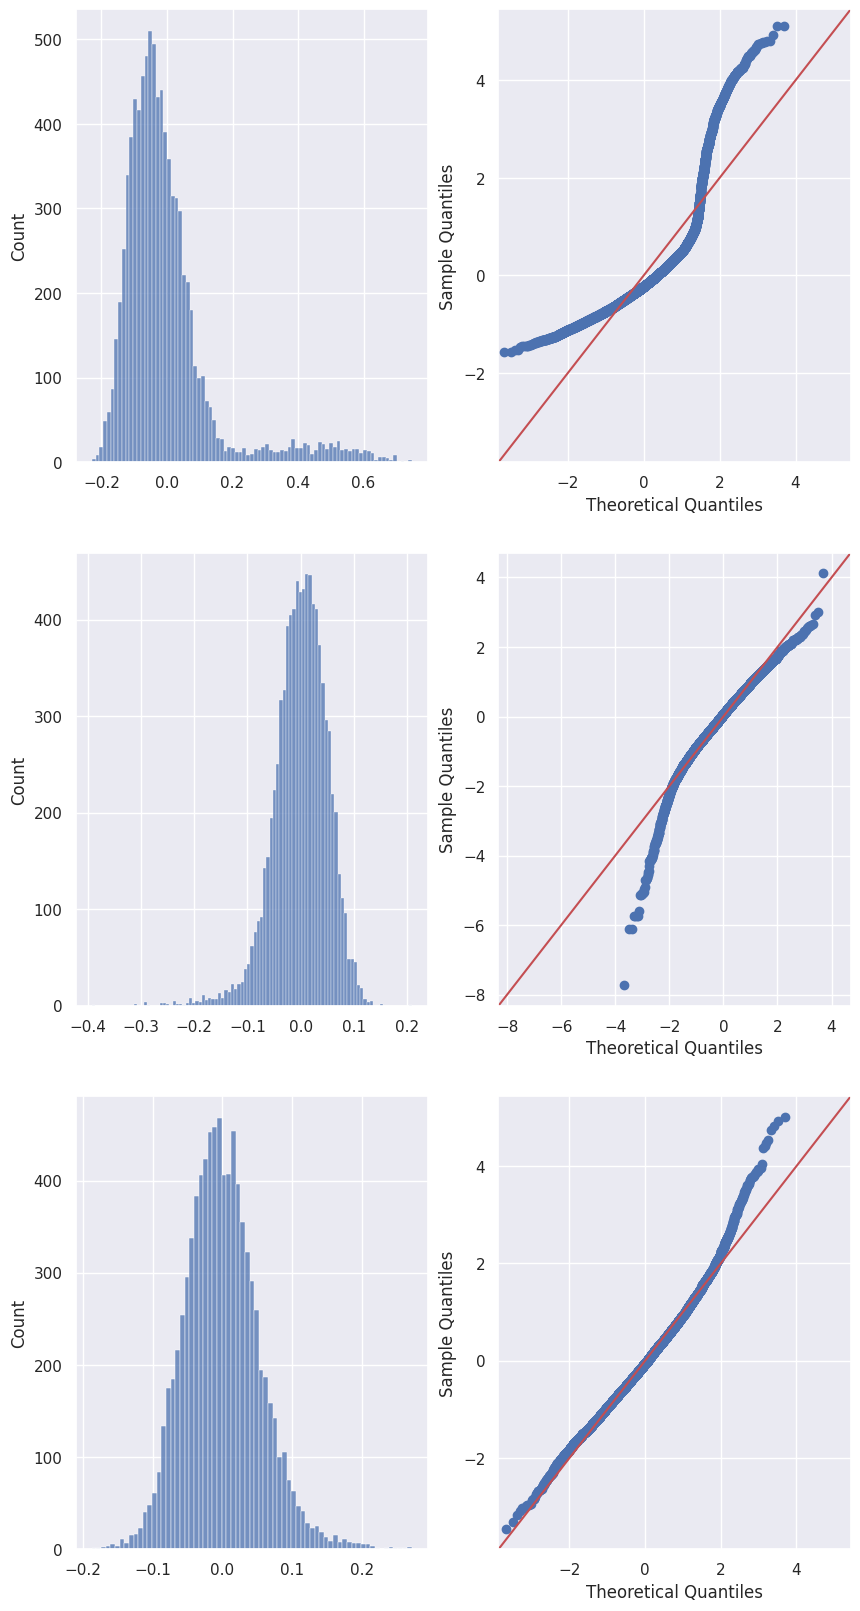

In [84]:
_, axes = plt.subplots(3, 2, figsize=(10, 20))

for i in range(3):
    v = rng.standard_normal((n, 1))
    v /= np.linalg.norm(v, axis=0)
    x_ = (vector_dataset - centroid) @ v[:,0]

    sns.histplot(x_, ax=axes[i][0])
    sm.qqplot(x_/x_.std(), ax=axes[i][1], line="45")
plt.show()